Dataset Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

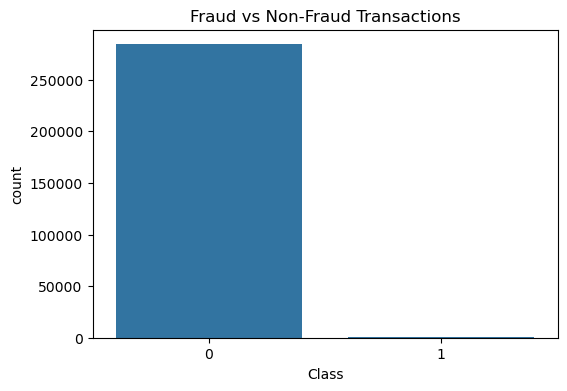


Class Distribution (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


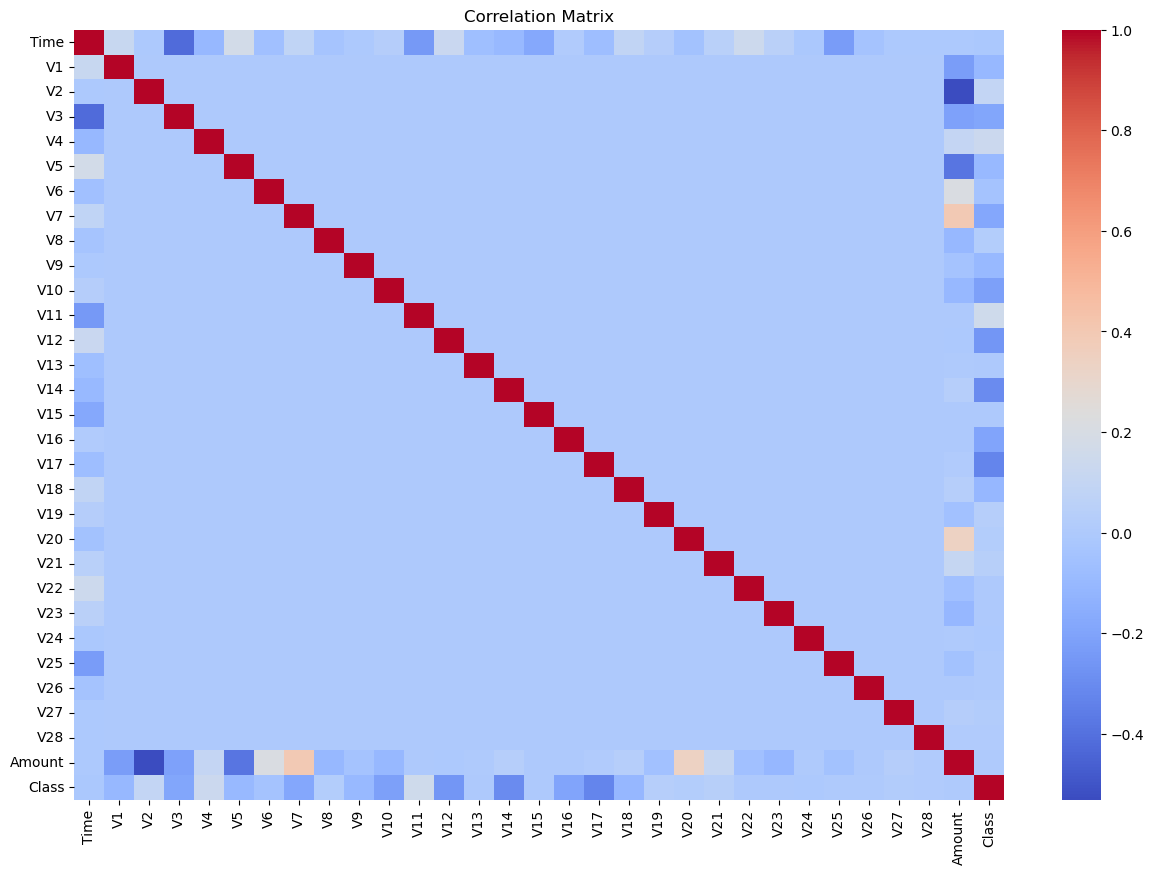

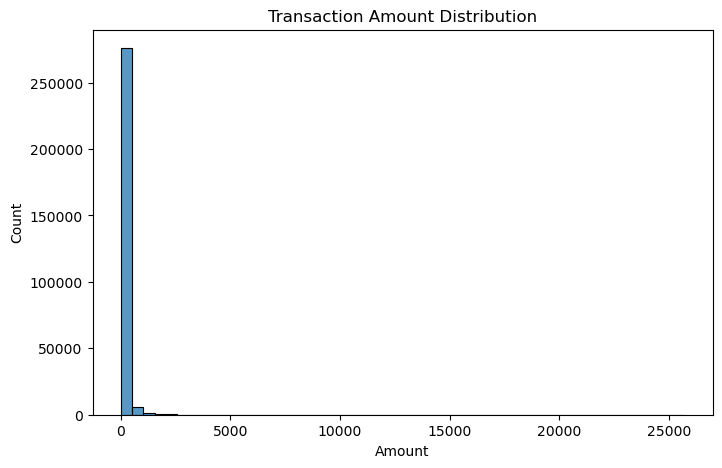


Target Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Training Shape: (227845, 30)
Testing Shape: (56962, 30)

===== LOGISTIC REGRESSION =====
Accuracy: 0.9754748779888347
Precision: 0.060851926977687626
Recall: 0.9183673469387755
F1 Score: 0.11414077362079898

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



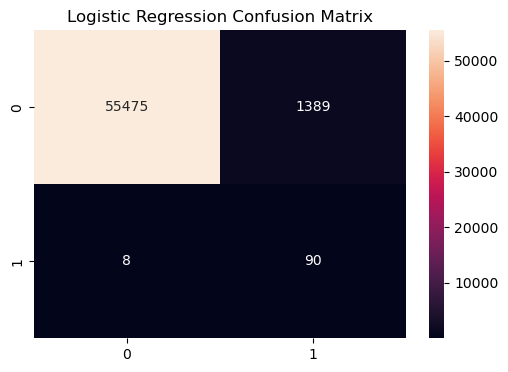


===== RANDOM FOREST =====
Accuracy: 0.9995084442259752
Precision: 0.9605263157894737
Recall: 0.7448979591836735
F1 Score: 0.8390804597701149

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Model Saved Successfully!
   Feature  Importance
13     V14    0.209898
9      V10    0.117569
3       V4    0.114797
16     V17    0.087271
11     V12    0.072567
10     V11    0.071818
2       V3    0.069107
15     V16    0.037077
6       V7    0.031452
1       V2    0.024929


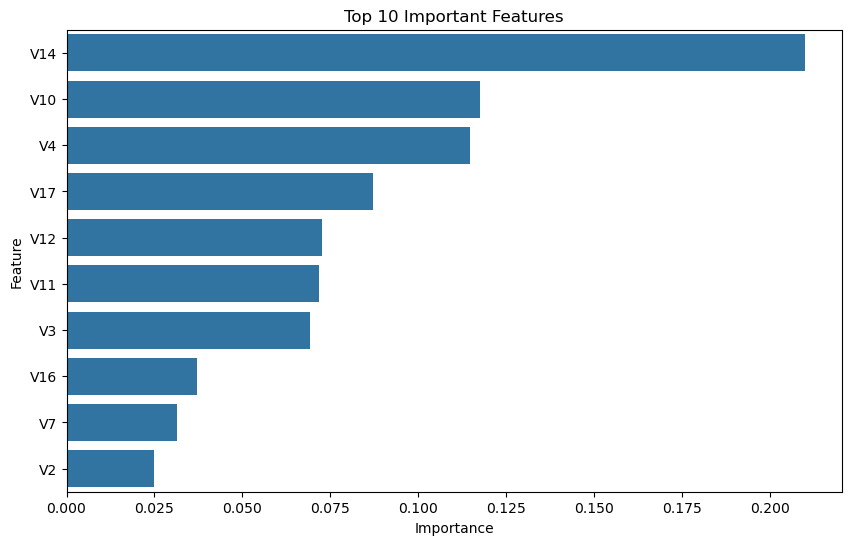


Project Completed Successfully!


In [1]:
# ==========================================
# CREDIT CARD FRAUD DETECTION PROJECT
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import joblib

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("data/creditcard.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

# Fraud Percentage
fraud_percent = (
    df['Class'].value_counts(normalize=True) * 100
)

print("\nClass Distribution (%):")
print(fraud_percent)

# Correlation Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

# ==========================================
# 3. PREPROCESSING
# ==========================================

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(
    df[['Amount']]
)

df['scaled_time'] = scaler.fit_transform(
    df[['Time']]
)

df.drop(['Time', 'Amount'], axis=1, inplace=True)

# ==========================================
# 4. SPLIT FEATURES AND TARGET
# ==========================================

X = df.drop('Class', axis=1)
y = df['Class']

print("\nTarget Distribution:")
print(y.value_counts())

# ==========================================
# 5. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ==========================================
# 6. LOGISTIC REGRESSION
# ==========================================

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n===== LOGISTIC REGRESSION =====")

print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Precision:",
      precision_score(y_test, y_pred_log))

print("Recall:",
      recall_score(y_test, y_pred_log))

print("F1 Score:",
      f1_score(y_test, y_pred_log))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_log
))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_log),
    annot=True,
    fmt='d'
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# ==========================================
# 7. RANDOM FOREST
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n===== RANDOM FOREST =====")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_rf
))

# ==========================================
# 8. SAVE BEST MODEL
# ==========================================

joblib.dump(rf_model,
            "models/fraud_model.pkl")

print("\nModel Saved Successfully!")

# ==========================================
# 9. FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

print("\nProject Completed Successfully!")